# Qubit spectroscopy (fixed LO, test version)

Same idea as `run06_broadband_qubit_spectroscopy.ipynb`, but this variant never issues `SetHardwareOption` on the drive LO -- it only sweeps the digital IF via `SetClockFrequency` around whatever drive LO is already configured in `hw_config`. Your original `hw_config` LO is never modified, and there is nothing to restore afterward. Trade-off: `FREQUENCY_WIDTH` must fit inside the IF bandwidth the hardware supports around that fixed LO -- there is no cal06-style branch splitting for wider searches.

In [2]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal06b_qubit_spectroscopy_fixed_lo import QubitSpectroscopyFixedLO

## Run parameters

In [3]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "qubit_spectroscopy_fixed_lo"

QUBITS = ["q10"]
FREQUENCY_CENTER = None  # None: use each qubit's own f01 from the device config
FREQUENCY_WIDTH = 100e6  # must fit within the IF bandwidth around the existing drive LO
FREQUENCY_POINTS = 11
REPETITIONS = 100
DRIVE_AMPLITUDE = 1
DRIVE_DURATION = 1

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config   # Use None if param persisting is not required

## Hardware and experiment

In [4]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = QubitSpectroscopyFixedLO(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [ ]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    repetitions=REPETITIONS,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


## Optional: view the compiled pulse schedule

`build_schedule()` wraps the sweep in a hardware loop that compiles to a single opaque `LoopOperation`, which `plot_pulse_diagram()` can't render. `preview_pulse_schedule()` builds a small loop-free stand-in instead, just for visual inspection of the pulse shape.

In [ ]:
experiment.preview_pulse_schedule(
    frequency_center=FREQUENCY_CENTER,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
)

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


## Optional: Simulated data

In [ ]:
# dataset = experiment.simulated_data(
#     frequency_center=FREQUENCY_CENTER,
#     frequency_width=FREQUENCY_WIDTH,
#     frequency_points=FREQUENCY_POINTS,
#     qubit_frequency=5.444e9,
#     linewidth=10e6,
#     phase_offset=0.0,
#     noise=0.002,
#     seed=42,
# )

## Analysis

In [ ]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: f01 = {result.frequency / 1e9:.9f} GHz, "
            f"linewidth = {result.linewidth / 1e6:.3f} MHz"
        )
    else:
        print(f"{qubit}: qubit-spectroscopy fit failed")

q10: f01 = 4.064730757 GHz, linewidth = 88.693 MHz


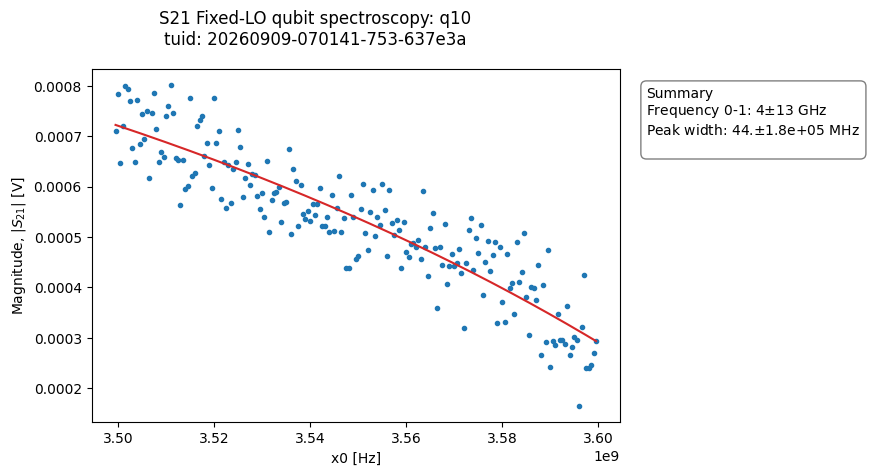

In [ ]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [ ]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

In [ ]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [1]:
from qcodes.instrument import Instrument

Instrument.close_all()